Max eigenvalue 0.6213508814991366
Stable
Simulated 67,979 events  (T=50000)
True  λ : [0.7121 0.6364]
Est.  λ : [0.7162 0.6434]
Error   : [0.0041 0.007 ]


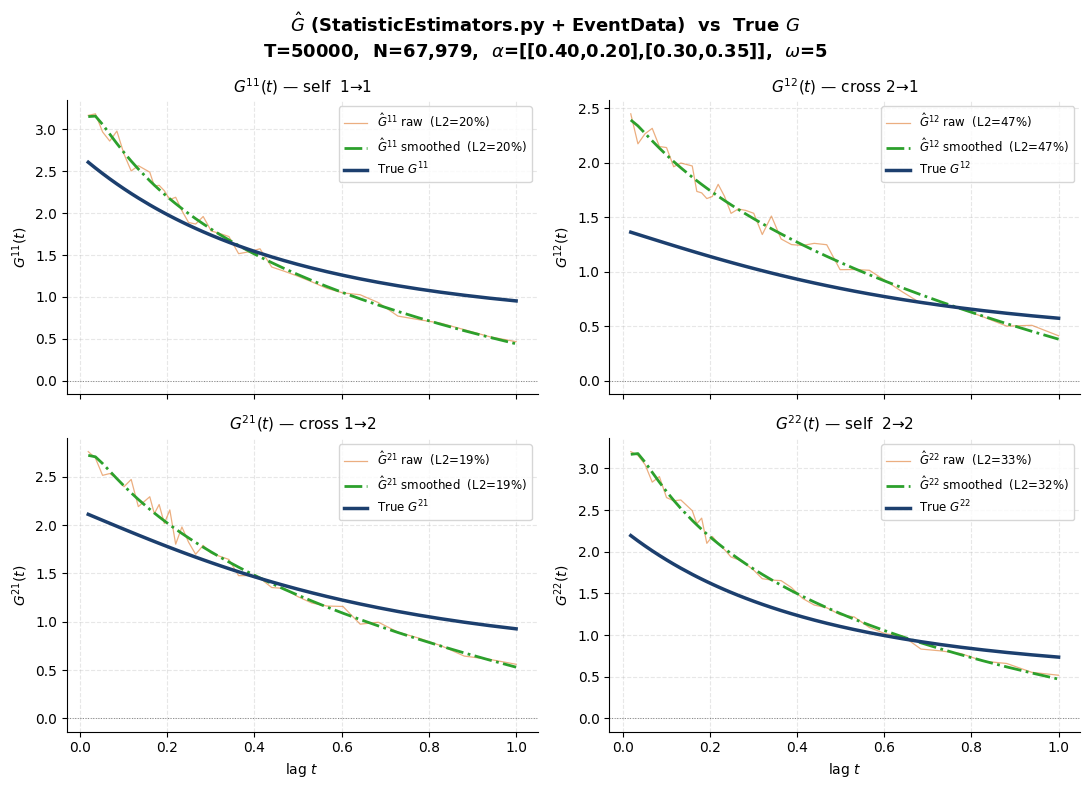

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.ndimage import gaussian_filter1d
from data import EventData
from StatisticEstimators import *
from MHP import MHP

# Ground-truth parameters 
alpha = np.array([[0.40, 0.20],
                  [0.30, 0.35]])
omega = 5.0
mu    = np.array([0.3, 0.2])
D     = 2

Lambda_true = np.linalg.solve(np.eye(D) - alpha, mu)

# Simulate 
horizon = 50_000.0
hp  = MHP(Phi=alpha, mu=mu, omega=omega)
hp.check_stability()
raw = hp.generate(horizon=horizon, seed=0)
print(f"Simulated {len(raw):,} events  (T={horizon:.0f})")

events = EventData(
    times  = raw[:, 0],
    types  = raw[:, 1].astype(int),
    marks  = np.ones(len(raw)),   # dummy  unused cause we can't find some in this simulation only for like csv
    horizon= horizon,
)

# Estimate statistics 

Lambda_hat       = estimate_Lambda(events)
lag_max, h       = 1.0, 0.15
G_hat, t_grid, _ = estimate_G(events, Lambda_hat,
                               lag_max=lag_max, h=h, n_lin=8, n_log=30)
# Spline-smooth in log-time 
G_smooth = smooth_G_spline(G_hat, t_grid, smooth_factor=None)

print(f"True  λ : {np.round(Lambda_true, 4)}")
print(f"Est.  λ : {np.round(Lambda_hat,  4)}")
print(f"Error   : {np.round(np.abs(Lambda_hat - Lambda_true), 5)}")

#true G 
A   = omega * (alpha - np.eye(D))
B   = omega * alpha @ np.diag(Lambda_true)
Gss = -np.linalg.inv(A) @ B
C   = alpha * omega

G_true = np.zeros((len(t_grid), D, D))
for k, t in enumerate(t_grid):
    G_true[k] = expm(A * t) @ C + Gss

# Plot 
CT, CE, CS = "#1C3F6E", "#D95F02", "#2CA02C"
label = {(0,0): "self  1→1", (0,1): "cross 2→1",
         (1,0): "cross 1→2", (1,1): "self  2→2"}

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
fig.suptitle(
    rf"$\hat G$ (StatisticEstimators.py + EventData)  vs  True $G$"
    f"\nT={horizon:.0f},  N={len(raw):,},  "
    r"$\alpha$=[[0.40,0.20],[0.30,0.35]],  $\omega$=5",
    fontsize=13, fontweight="bold"
)

for i in range(D):
    for j in range(D):
        ax = axes[i, j]
        tv = G_true[:, i, j]
        ev = G_hat[i, j, :]
        sv = G_smooth[i, j, :]

        rl2_raw = (np.sqrt(np.trapezoid((tv-ev)**2, t_grid))
                   / (np.sqrt(np.trapezoid(tv**2, t_grid)) + 1e-12)) * 100
        rl2_smo = (np.sqrt(np.trapezoid((tv-sv)**2, t_grid))
                   / (np.sqrt(np.trapezoid(tv**2, t_grid)) + 1e-12)) * 100

        ax.plot(t_grid, ev, color=CE, lw=0.9, alpha=0.5,
                label=rf"$\hat G^{{{i+1}{j+1}}}$ raw  (L2={rl2_raw:.0f}%)")
        ax.plot(t_grid, sv, color=CS, lw=2.0, ls="-.",
                label=rf"$\hat G^{{{i+1}{j+1}}}$ smoothed  (L2={rl2_smo:.0f}%)")
        ax.plot(t_grid, tv, color=CT, lw=2.5,
                label=rf"True $G^{{{i+1}{j+1}}}$")
        ax.axhline(0, color="gray", lw=0.7, ls=":")

        ax.set_title(rf"$G^{{{i+1}{j+1}}}(t)$ — {label[(i,j)]}", fontsize=11)
        ax.set_ylabel(rf"$G^{{{i+1}{j+1}}}(t)$")
        if i == 1:
            ax.set_xlabel("lag $t$")
        ax.legend(fontsize=8.5, loc="upper right")
        ax.grid(ls="--", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

TEST 1



Training row 0 ...
  row 0  ep 0000  loss=2.2848e+00
  row 0  ep 0150  loss=1.8796e-03
  row 0  ep 0300  loss=5.0895e-05
  row 0  ep 0450  loss=2.6089e-05
  row 0  ep 0599  loss=2.4112e-05

Training row 1 ...
  row 1  ep 0000  loss=7.6286e+00
  row 1  ep 0150  loss=1.0061e-03
  row 1  ep 0300  loss=1.1336e-04
  row 1  ep 0450  loss=1.0055e-04
  row 1  ep 0599  loss=9.7783e-05


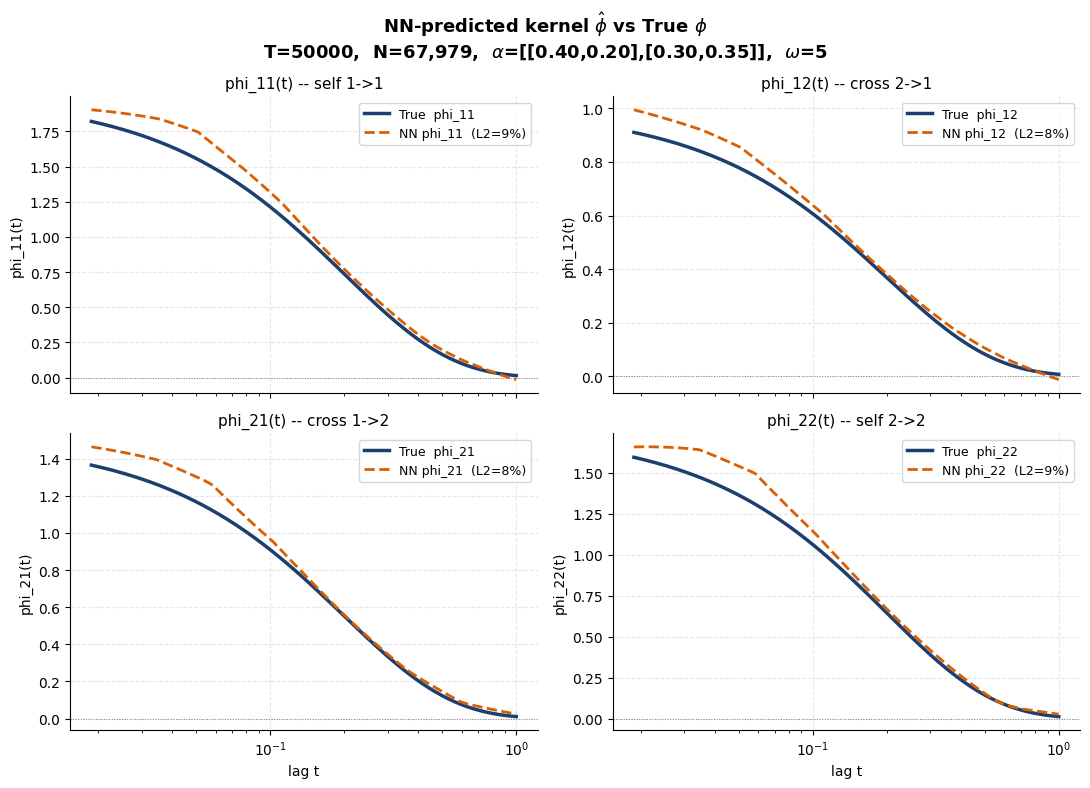

In [ ]:

import torch
from models import KernelRowNet
from StatisticEstimators import build_H

torch.manual_seed(42)
device = torch.device("cpu")

# G_smooth lives on t_grid 
G_grid = t_grid          # Q=38 the grid G_smooth is defined on

#   quadrature grid
t_np = np.logspace(np.log10(G_grid[0]), np.log10(G_grid[-1]), 800)
Q    = len(t_np)

edges = np.concatenate([[t_np[0] - 0.5*(t_np[1]-t_np[0])],
                         0.5*(t_np[:-1]+t_np[1:]),
                        [t_np[-1] + 0.5*(t_np[-1]-t_np[-2])]])
w_np = np.diff(edges)    # [Q] quadrature weights

t_th = torch.tensor(t_np, dtype=torch.float32)
w_th = torch.tensor(w_np, dtype=torch.float32)

# Compute H for integral
H_func = build_H(G_smooth, G_grid, Lambda_hat)
diff   = t_np[:, None] - t_np[None, :]       
H_np = np.zeros((Q, Q, D, D))
for k in range(D):
    for j in range(D):
        H_np[:, :, k, j] = H_func(k, j, diff.ravel()).reshape(Q, Q)

H_th = torch.tensor(H_np, dtype=torch.float32)   # [Q, Q, D, D]

# Resample G_smooth target onto the quadrature grid 
G_on_quad = np.zeros((D, D, Q))
for i in range(D):
    for j in range(D):
        G_on_quad[i, j] = np.interp(t_np, G_grid, G_smooth[i, j])
G_quad_th = torch.tensor(G_on_quad, dtype=torch.float32)   # [D, D, Q]

#  Train one row 
def train_row(row_i, epochs=600, lr=3e-3):
    model = KernelRowNet(input_dim=2, hidden_dim=64, output_dim=D, n_layers=3).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=5e-5)

    log_t   = torch.log10(t_th.clamp_min(1e-8))   # [Q]
    x_dummy = torch.ones_like(log_t)               # dummy mark = 1 (unmarked)
    target  = G_quad_th[row_i].T                   # [Q, D]

    for ep in range(epochs):
        model.train()
        phi = model(log_t, x_dummy)                # [Q, D]

        # integral[n,j] = sum_k sum_q  w_q * phi[q,k] * H[n,q,k,j]
        phi_w    = phi * w_th[:, None]             # [Q, D]
        integral = torch.einsum('qk,nqkj->nj', phi_w, H_th)   # [Q, D]

        loss = (phi + integral - target).pow(2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
        sched.step()

        if ep % 150 == 0 or ep == epochs - 1:
            print(f"  row {row_i}  ep {ep:04d}  loss={loss.item():.4e}")

    return model

print("\nTraining row 0")
model0 = train_row(0)
print("\nTraining row 1")
model1 = train_row(1)
trained_models = [model0, model1]

# Predict on a fine time grid 
t_fine   = np.logspace(np.log10(t_np[0]), np.log10(t_np[-1]), 200)
log_fine = torch.log10(torch.tensor(t_fine, dtype=torch.float32).clamp_min(1e-8))
x_fine   = torch.ones_like(log_fine)

phi_pred      = np.zeros((D, D, len(t_fine)))
phi_true_fine = np.zeros_like(phi_pred)

for i in range(D):
    trained_models[i].eval()
    with torch.no_grad():
        out = trained_models[i](log_fine, x_fine).numpy()   # [L, D]
    phi_pred[i] = out.T

for i in range(D):
    for j in range(D):
        phi_true_fine[i, j] = alpha[i, j] * omega * np.exp(-omega * t_fine)

# Plot 
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
fig.suptitle(
    r"NN-predicted kernel $\hat\phi$ vs True $\phi$"
    f"\nT={horizon:.0f},  N={len(raw):,},  "
    r"$\alpha$=[[0.40,0.20],[0.30,0.35]],  $\omega$=5",
    fontsize=13, fontweight="bold"
)
lbl = {(0,0):"self 1->1", (0,1):"cross 2->1",
       (1,0):"cross 1->2", (1,1):"self 2->2"}

for i in range(D):
    for j in range(D):
        ax = axes[i, j]
        pt = phi_true_fine[i, j]
        pp = phi_pred[i, j]
        rl2 = (np.sqrt(np.trapezoid((pt-pp)**2, t_fine))
               / (np.sqrt(np.trapezoid(pt**2, t_fine)) + 1e-12)) * 100

        ax.plot(t_fine, pt, color="#1C3F6E", lw=2.5,  label=f"True  phi_{i+1}{j+1}")
        ax.plot(t_fine, pp, color="#D95F02", lw=2.0, ls="--",
                label=f"NN phi_{i+1}{j+1}  (L2={rl2:.0f}%)")
        ax.axhline(0, color="gray", lw=0.7, ls=":")
        ax.set_xscale("log")
        ax.set_title(f"phi_{i+1}{j+1}(t) -- {lbl[(i,j)]}", fontsize=11)
        ax.set_ylabel(f"phi_{i+1}{j+1}(t)")
        if i == 1: ax.set_xlabel("lag t")
        ax.legend(fontsize=9)
        ax.grid(ls="--", alpha=0.3)
        ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()


TEST 2  with temporal + causal weighting  

ζ weights:
[[0.2349 0.2874]
 [0.2429 0.2347]]

Training row 0
  [row 0] ep 0000  lr=9.971e-04  train=1.9777e-01  val=2.8074e+00  best=2.8074e+00@ep0
  [row 0] ep 0100  lr=7.477e-04  train=1.5203e-03  val=3.0565e-02  best=3.0565e-02@ep100
  [row 0] ep 0200  lr=5.607e-04  train=8.3428e-05  val=1.5549e-03  best=1.5549e-03@ep200
  [row 0] ep 0300  lr=4.205e-04  train=9.6135e-06  val=1.8360e-04  best=1.8360e-04@ep300
  [row 0] ep 0400  lr=3.153e-04  train=7.0716e-06  val=1.3560e-04  best=1.3560e-04@ep400
  [row 0] ep 0500  lr=2.365e-04  train=5.7281e-06  val=1.1075e-04  best=1.1075e-04@ep500
  [row 0] ep 0600  lr=1.773e-04  train=4.9484e-06  val=9.6092e-05  best=9.6092e-05@ep600
  [row 0] ep 0700  lr=1.330e-04  train=4.4611e-06  val=8.6810e-05  best=8.6810e-05@ep700
  [row 0] ep 0799  lr=1.000e-04  train=4.1273e-06  val=8.0386e-05  best=8.0386e-05@ep799
  → loaded best checkpoint (ep 799, val=8.0386e-05)

Training row 1
  [row 1] ep 0000  lr=9.971e-04  train=1.8975e-01  val=2.6872e+00  best

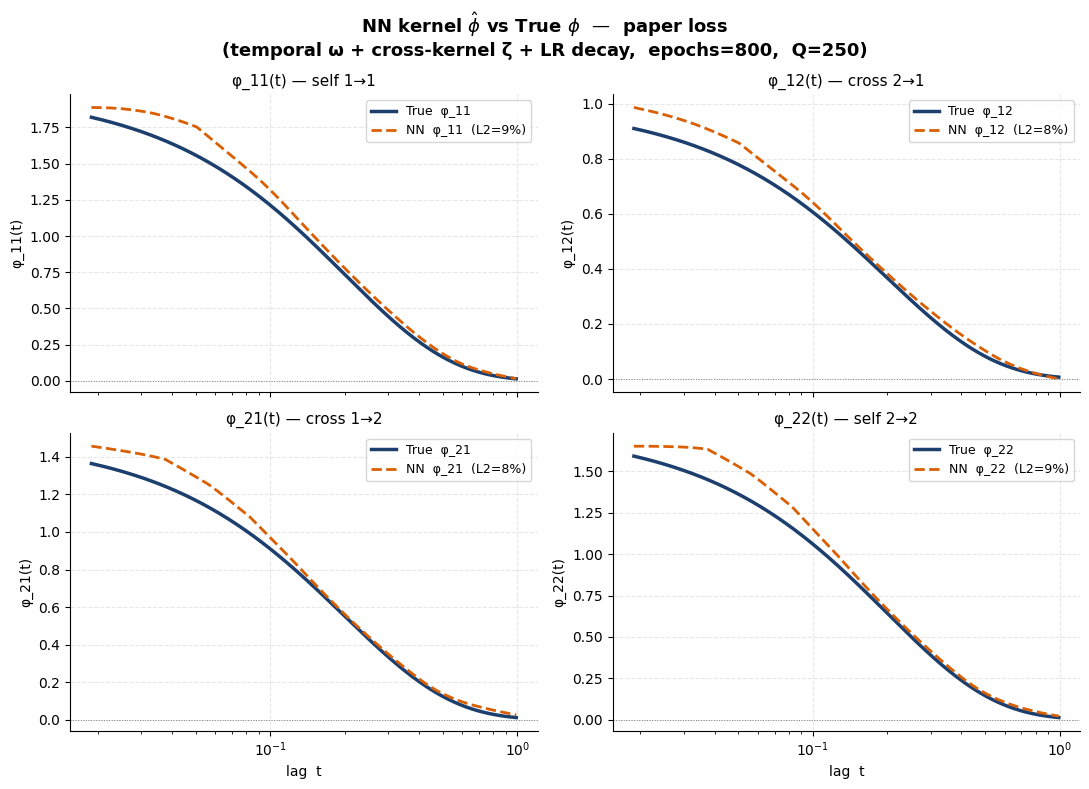

In [ ]:

import torch
import copy
import numpy as np
import matplotlib.pyplot as plt
from models import KernelRowNet
from StatisticEstimators import build_H
from loss import temporal_weights

torch.manual_seed(42)
device = torch.device("cpu")

# Hyperparameters 
HIDDEN      = 256
LAYERS      = 32
LR0         = 1e-3
EPOCHS      = 800
Q           = 250       
EPS_W       = 5.0       
PRINT_EVERY = 100

#  grid 
t_min  = t_grid[0]
T      = lag_max

e1 = np.logspace(np.log10(t_min), np.log10(0.05),  80 + 1)  # short lag
e2 = np.logspace(np.log10(0.05),  np.log10(0.3),   100 + 1) # peak region  
e3 = np.logspace(np.log10(0.3),   np.log10(T),      70 + 1) # tail

edges = np.unique(np.concatenate([e1, e2[1:], e3[1:]]))
t_np  = 0.5 * (edges[:-1] + edges[1:])
w_np  = np.diff(edges)

"""edges  = np.logspace(np.log10(t_min), np.log10(T), Q + 1)
t_np   = 0.5 * (edges[:-1] + edges[1:])   # midpoints  [Q]
w_np   = np.diff(edges)                    # widths      [Q]
"""
t_th   = torch.tensor(t_np, dtype=torch.float32)
w_th   = torch.tensor(w_np, dtype=torch.float32)

# Build H for the integral
H_func = build_H(G_smooth, t_grid, Lambda_hat)
diff   = t_np[:, None] - t_np[None, :]         
H_np   = np.zeros((Q, Q, D, D))
for k in range(D):
    for j in range(D):
        H_np[:, :, k, j] = H_func(k, j, diff.ravel()).reshape(Q, Q)
H_th = torch.tensor(H_np, dtype=torch.float32)  


# G target resampled onto quadrature grid 
G_on_quad = np.zeros((D, D, Q))
for i in range(D):
    for j in range(D):
        G_on_quad[i, j] = np.interp(t_np, t_grid, G_smooth[i, j])
G_quad_th = torch.tensor(G_on_quad, dtype=torch.float32)  # [D, D, Q]

#  Cross-kernel \zeta weights 
areas     = torch.trapezoid(G_quad_th.abs(), t_th, dim=2)  
inv_areas = 1.0 / areas.clamp_min(1e-8)
zeta      = inv_areas / inv_areas.sum()                    # [D, D]
print(f"$\zeta$ weights:\n{zeta.numpy().round(4)}")


def train_row_paper(row_i):
    """
    we train one KernelRowNet for row i using the paper's full loss.
    Collocation = quadrature grid (Q fixed points, sorted by time).
    Each epoch:
      1. [no_grad] compute residuals to temporal weights $\omega$  (Eq. 22)
      2. forward pass to loss = mean(\zeta_{ij} · \omega_{nj} · residual^2_{nj})
    LR schedule: $\gamma_e = \gamma_0 \cdot 100^{-(e+1)/E}$   (Algorithm 1)
    """
    model   = KernelRowNet(input_dim=2, hidden_dim=HIDDEN, output_dim=D, n_layers=LAYERS).to(device)
    opt     = torch.optim.Adam(model.parameters(), lr=LR0)

    log_t    = torch.log10(t_th.clamp_min(1e-8))   # [Q]
    x_dummy  = torch.ones_like(log_t)               # unmarked: x = 1
    target   = G_quad_th[row_i].T                   # [Q, D]
    zeta_row = zeta[row_i]                           # [D]

    best_val, best_epoch, best_state = float("inf"), -1, None

    for ep in range(EPOCHS):
        # LR decay 
        lr = LR0 * (10.0 ** (-(ep + 1) / EPOCHS))
        for g in opt.param_groups:
            g["lr"] = lr

        # Temporal weights 
        model.eval()
        with torch.no_grad():
            phi_ng   = model(log_t, x_dummy)                        # [Q, D]
            phi_w_ng = phi_ng * w_th[:, None]                       # [Q, D]
            int_ng   = torch.einsum("qk,nqkj->nj", phi_w_ng, H_th) # [Q, D]
            res_ng   = phi_ng + int_ng - target                     # [Q, D]
            omega_w  = temporal_weights(res_ng, eps=EPS_W)          # [Q, D]

        # Forward + weighted loss 
        model.train()
        opt.zero_grad()
        phi      = model(log_t, x_dummy)                            # [Q, D]
        phi_w    = phi * w_th[:, None]                              # [Q, D]
        integral = torch.einsum("qk,nqkj->nj", phi_w, H_th)        # [Q, D]
        residual = phi + integral - target                          # [Q, D]

        # to check and try other stuff
        loss = (zeta_row * omega_w.detach() * residual.square()).mean()
        loss.backward()
        opt.step()

        # Validation to check not sure
        model.eval()
        with torch.no_grad():
            phi_v    = model(log_t, x_dummy)
            int_v    = torch.einsum("qk,nqkj->nj", phi_v * w_th[:, None], H_th)
            val_loss = (phi_v + int_v - target).square().mean().item()

        if val_loss < best_val:
            best_val, best_epoch = val_loss, ep
            best_state = copy.deepcopy(model.state_dict())

        if ep % PRINT_EVERY == 0 or ep == EPOCHS - 1:
            print(f"  [row {row_i}] ep {ep:04d}  lr={lr:.3e}  "
                  f"train={loss.item():.4e}  val={val_loss:.4e}  "
                  f"best={best_val:.4e}@ep{best_epoch}")

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"  to loaded best checkpoint (ep {best_epoch}, val={best_val:.4e})")
    return model


# Train all rows
trained_models = []
for row_i in range(D):
    print(f"\n{'='*60}\nTraining row {row_i}\n{'='*60}")
    m = train_row_paper(row_i)
    trained_models.append(m)


#  Predict
t_fine   = np.logspace(np.log10(t_np[0]), np.log10(t_np[-1]), 300)
log_fine = torch.log10(torch.tensor(t_fine, dtype=torch.float32).clamp_min(1e-8))
x_fine   = torch.ones_like(log_fine)

phi_pred      = np.zeros((D, D, len(t_fine)))
phi_true_fine = np.zeros_like(phi_pred)

for i in range(D):
    trained_models[i].eval()
    with torch.no_grad():
        out = trained_models[i](log_fine, x_fine).numpy()  # [L, D]
    phi_pred[i] = out.T

for i in range(D):
    for j in range(D):
        phi_true_fine[i, j] = alpha[i, j] * omega * np.exp(-omega * t_fine)

# Plot 
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
fig.suptitle(
    r"NN kernel $\hat\phi$ vs True $\phi$  —  paper loss"
    f"\n(temporal $\omega$ + cross-kernel $\zeta$ + LR decay,  epochs={EPOCHS},  Q={Q})",
    fontsize=13, fontweight="bold"
)
lbl = {(0,0): "self 1→1", (0,1): "cross 2→1",
       (1,0): "cross 1→2", (1,1): "self 2→2"}

for i in range(D):
    for j in range(D):
        ax  = axes[i, j]
        pt  = phi_true_fine[i, j]
        pp  = phi_pred[i, j]
        rl2 = (np.sqrt(np.trapezoid((pt - pp)**2, t_fine))
               / (np.sqrt(np.trapezoid(pt**2, t_fine)) + 1e-12)) * 100

        ax.plot(t_fine, pt, color="#1C3F6E", lw=2.5, label=f"True  $\phi_{i+1}{j+1}$")
        ax.plot(t_fine, pp, color="#D95F02", lw=2.0, ls="--",
                label=f"NN  $\phi_{i+1}{j+1}$  (L2={rl2:.0f}%)")
        ax.axhline(0, color="gray", lw=0.7, ls=":")
        ax.set_xscale("log")
        ax.set_title(f"$\phi_{i+1}{j+1}(t)$ — {lbl[(i,j)]}", fontsize=11)
        ax.set_ylabel(f"$\phi_{i+1}{j+1}(t)$")
        if i == 1:
            ax.set_xlabel("lag  t")
        ax.legend(fontsize=9)
        ax.grid(ls="--", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


Test 3 Parameters as close as the ref paper with true loss

In [ ]:
import torch
import copy
import numpy as np
import matplotlib.pyplot as plt
from models import KernelRowNet
from StatisticEstimators import build_H
from loss import temporal_weights
device = torch.device('cpu')

# Hyperparameters
HIDDEN      = 64       # neurons per hidden layer
LAYERS      = 1        # DGM depth (number of hidden layers)
LR0         = 1e-3     # learning rate
Q           = 250      # quadrature points (for integral approximation)
BATCH_SIZE  = 8        # collocation mini-batch size per gradient step
TRAIN_SIZE  = 1024     # total collocation training points
VAL_SIZE    = 128      # collocation validation points
EPOCHS      = 500     # training epochs
EPS_W       = 5.0      # epsilon for temporal_weights 
PRINT_EVERY = 100

t_min = t_grid[0]
T     = lag_max

# Fixed quadrature grid (for integral approximation)
e1 = np.logspace(np.log10(t_min), np.log10(0.05),  80 + 1)
e2 = np.logspace(np.log10(0.05),  np.log10(0.3),   100 + 1)
e3 = np.logspace(np.log10(0.3),   np.log10(T),      70 + 1)
edges = np.unique(np.concatenate([e1, e2[1:], e3[1:]]))
t_np  = 0.5 * (edges[:-1] + edges[1:])
w_np  = np.diff(edges)
t_th  = torch.tensor(t_np, dtype=torch.float32)
w_th  = torch.tensor(w_np, dtype=torch.float32)

# Random collocation grids 
rng        = np.random.default_rng(42)
t_train_np = np.sort(rng.uniform(t_min, T, TRAIN_SIZE))
t_val_np   = np.sort(rng.uniform(t_min, T, VAL_SIZE))

# Precompute H for collocation grids
H_func = build_H(G_smooth, t_grid, Lambda_hat)

def compute_H_coll(t_coll, t_quad, H_func, D):
    N, Qq = len(t_coll), len(t_quad)
    diff  = t_coll[:, None] - t_quad[None, :]   # (N, Q)
    H     = np.zeros((N, Qq, D, D))
    for k in range(D):
        for j in range(D):
            H[:, :, k, j] = H_func(k, j, diff.ravel()).reshape(N, Qq)
    return torch.tensor(H, dtype=torch.float32)

print('Precomputing H for training collocation points ')
H_train_th = compute_H_coll(t_train_np, t_np, H_func, D)   # (TRAIN_SIZE, Q, D, D)
print('Precomputing H for validation collocation points ')
H_val_th   = compute_H_coll(t_val_np,   t_np, H_func, D)   # (VAL_SIZE,   Q, D, D)

# Targets: G_smooth interpolated at collocation points
def interp_G_target(t_coll):
    G_interp = np.zeros((D, D, len(t_coll)))
    for i in range(D):
        for j in range(D):
            G_interp[i, j] = np.interp(t_coll, t_grid, G_smooth[i, j])
    return torch.tensor(G_interp, dtype=torch.float32)

G_train_th = interp_G_target(t_train_np)   # (D, D, TRAIN_SIZE)
G_val_th   = interp_G_target(t_val_np)     # (D, D, VAL_SIZE)

# Log-time inputs (training points are pre-sorted for temporal_weights)
log_t_train = torch.log10(torch.tensor(t_train_np, dtype=torch.float32).clamp_min(1e-8))
x_train     = torch.ones_like(log_t_train)
log_t_val   = torch.log10(torch.tensor(t_val_np,   dtype=torch.float32).clamp_min(1e-8))
x_val       = torch.ones_like(log_t_val)
log_t_quad  = torch.log10(t_th.clamp_min(1e-8))
x_quad      = torch.ones_like(log_t_quad)

# Training loop
def train_row_dgm(row_i):
    model = KernelRowNet(input_dim=2, hidden_dim=HIDDEN, output_dim=D, n_layers=LAYERS).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=LR0, weight_decay=1e-6)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-6)

    target_train = G_train_th[row_i].T   # (TRAIN_SIZE, D)
    target_val   = G_val_th[row_i].T     # (VAL_SIZE, D)

    best_val, best_epoch, best_state = float('inf'), -1, None
    patience, no_improve = 120, 0
    steps_per_epoch = TRAIN_SIZE // BATCH_SIZE

    for ep in range(EPOCHS):
        
        model.eval()
        with torch.no_grad():
            phi_all    = model(log_t_train, x_train)                             # (TRAIN_SIZE, D)
            phi_q_ng   = model(log_t_quad, x_quad)                               # (Q, D)
            int_all    = torch.einsum('qk,nqkj->nj', phi_q_ng * w_th[:, None], H_train_th)  # (TRAIN_SIZE, D)
            res_all    = phi_all + int_all - target_train                        # (TRAIN_SIZE, D)
            w_all      = temporal_weights(res_all, eps=EPS_W)                   # (TRAIN_SIZE, D)  Eq.(22)

        model.train()
        perm       = torch.randperm(TRAIN_SIZE)
        epoch_loss = 0.0

        for step in range(steps_per_epoch):
            idx   = perm[step * BATCH_SIZE : (step + 1) * BATCH_SIZE]
            H_b   = H_train_th[idx]          # (BATCH_SIZE, Q, D, D)
            tgt_b = target_train[idx]        # (BATCH_SIZE, D)
            w_b   = w_all[idx]               # (BATCH_SIZE, D)  fixed, Eq.(22)

            phi_b    = model(log_t_train[idx], x_train[idx])        # (BATCH_SIZE, D)
            phi_quad = model(log_t_quad, x_quad)                     # (Q, D)
            integral = torch.einsum('qk,nqkj->nj', phi_quad * w_th[:, None], H_b)  # (BATCH_SIZE, D)
            residual = phi_b + integral - tgt_b                      # eps_n^ij  Eq.(19)

            # loss with weights 
            loss = (w_b * residual.square()).mean()

            opt.zero_grad()
            loss.backward()
            opt.step()
            epoch_loss += loss.item()

        sched.step()

        # -- Validation: unweighted Eq.(25)
        model.eval()
        with torch.no_grad():
            phi_v  = model(log_t_val, x_val)
            phi_qv = model(log_t_quad, x_quad)
            int_v  = torch.einsum('qk,nqkj->nj', phi_qv * w_th[:, None], H_val_th)
            val_loss = (phi_v + int_v - target_val).square().mean().item()  # Eq.(25)

        if val_loss < best_val:
            best_val, best_epoch = val_loss, ep
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if ep % PRINT_EVERY == 0 or ep == EPOCHS - 1:
            print(f'  [row {row_i}] ep {ep:04d}  lr={opt.param_groups[0]["lr"]:.3e}  '
                  f'train={epoch_loss/steps_per_epoch:.4e}  val={val_loss:.4e}  '
                  f'best={best_val:.4e}@ep{best_epoch}')


    if best_state is not None:
        model.load_state_dict(best_state)
    print(f'  -> loaded best checkpoint (ep {best_epoch}, val={best_val:.4e})')
    return model


trained_models = []
for row_i in range(D):
    print(f"\n{'='*60}\nTraining row {row_i}\n{'='*60}")
    trained_models.append(train_row_dgm(row_i))


# Predict on fine grid
t_fine   = np.logspace(np.log10(t_np[0]), np.log10(t_np[-1]), 300)
log_fine = torch.log10(torch.tensor(t_fine, dtype=torch.float32).clamp_min(1e-8))
x_fine   = torch.ones_like(log_fine)

phi_pred      = np.zeros((D, D, len(t_fine)))
phi_true_fine = np.zeros_like(phi_pred)

for i in range(D):
    trained_models[i].eval()
    with torch.no_grad():
        phi_pred[i] = trained_models[i](log_fine, x_fine).numpy().T

for i in range(D):
    for j in range(D):
        phi_true_fine[i, j] = alpha[i, j] * omega * np.exp(-omega * t_fine)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
fig.suptitle(
    r'NN kernel $\hat\phi$ vs True $\phi$  --  DGM + paper loss Eq.(26)'
    f'\n(neurons={HIDDEN}, depth={LAYERS}, Q={Q}, batch={BATCH_SIZE}, '
    f'train={TRAIN_SIZE}, val={VAL_SIZE}, epochs={EPOCHS})',
    fontsize=13, fontweight='bold')
lbl = {(0,0): 'self 1->1', (0,1): 'cross 2->1',
       (1,0): 'cross 1->2', (1,1): 'self 2->2'}

for i in range(D):
    for j in range(D):
        ax  = axes[i, j]
        pt  = phi_true_fine[i, j]
        pp  = phi_pred[i, j]
        rl2 = (np.sqrt(np.trapezoid((pt - pp)**2, t_fine))
               / (np.sqrt(np.trapezoid(pt**2, t_fine)) + 1e-12)) * 100
        ax.plot(t_fine, pt, color='#1C3F6E', lw=2.5, label=f'True  $\phi_{i+1}{j+1}$')
        ax.plot(t_fine, pp, color='#D95F02', lw=2.0, ls='--',
                label=f'NN  $\phi_{i+1}{j+1}  (L2={rl2:.0f}%)')
        ax.axhline(0, color='gray', lw=0.7, ls=':')
        ax.set_xscale('log')
        ax.set_title(f'$phi_{i+1}{j+1}(t)$ -- {lbl[(i,j)]}', fontsize=11)
        ax.set_ylabel(f'$phi_{i+1}{j+1}(t)$')
        if i == 1:
            ax.set_xlabel('lag  t')
        ax.legend(fontsize=9)
        ax.grid(ls='--', alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


Test 4 Full Model not great


Max eigenvalue 0.6213508814991366
Stable
Simulated 13,232 events
Saved to events_sim.csv

Training row 0/1
[row 0] epoch 0000 lr=9.908e-04 train=7.225698e-02 val=1.603863e-01 best_val=1.603863e-01 best_epoch=0
[row 0] epoch 0050 lr=6.252e-04 train=1.992034e-03 val=9.844780e-03 best_val=7.049678e-03 best_epoch=42
[row 0] epoch 0100 lr=3.945e-04 train=1.228148e-03 val=5.719607e-03 best_val=4.209943e-03 best_epoch=91
[row 0] epoch 0150 lr=2.489e-04 train=9.743507e-04 val=4.988096e-03 best_val=3.408899e-03 best_epoch=119
[row 0] epoch 0200 lr=1.570e-04 train=1.006862e-03 val=4.059966e-03 best_val=3.354661e-03 best_epoch=154
[row 0] epoch 0250 lr=9.908e-05 train=9.851831e-04 val=4.713470e-03 best_val=3.159637e-03 best_epoch=221
[row 0] epoch 0300 lr=6.252e-05 train=7.928375e-04 val=4.039086e-03 best_val=2.854305e-03 best_epoch=281
[row 0] epoch 0350 lr=3.945e-05 train=7.534331e-04 val=4.065962e-03 best_val=2.711201e-03 best_epoch=312
[row 0] epoch 0400 lr=2.489e-05 train=8.187876e-04 val=3.

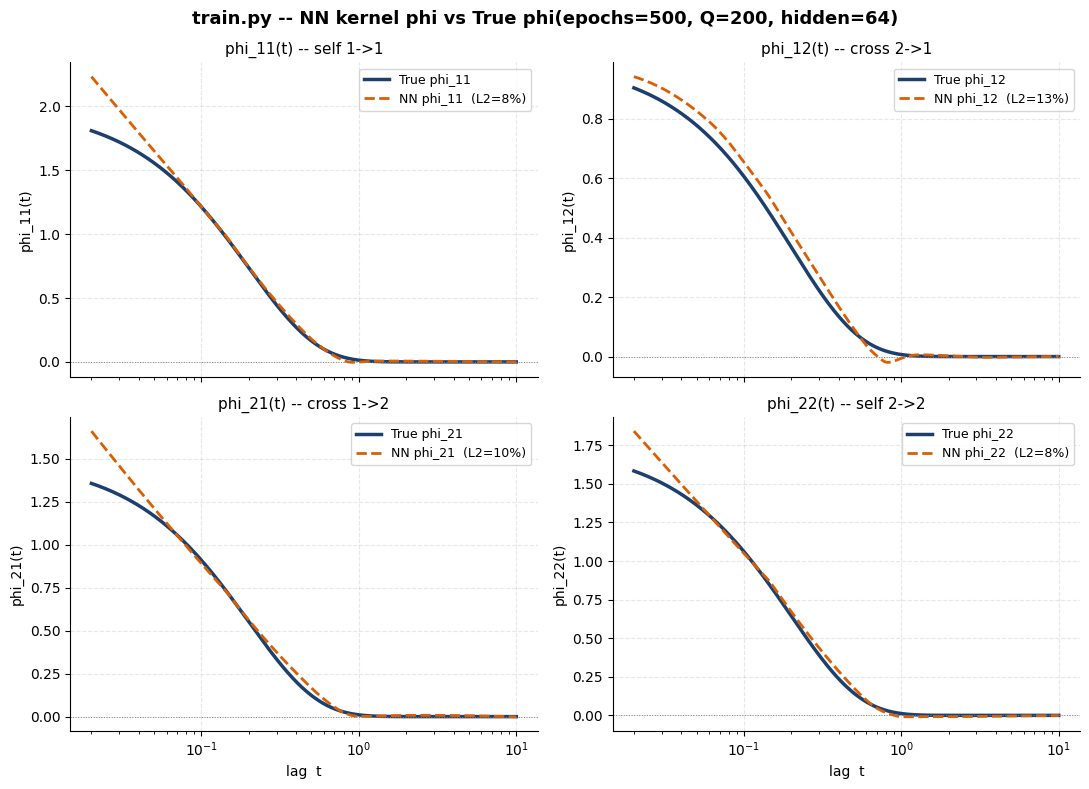

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from MHP import MHP
from train import Config, train_all_rows, predict_row_on_grid

# 1. Simulate data and save to CSV (train.py expects a CSV with time/type/mark columns)
alpha = np.array([[0.40, 0.20],
                  [0.30, 0.35]])
omega = 5.0
mu    = np.array([0.3, 0.2])

hp  = MHP(Phi=alpha, mu=mu, omega=omega)
hp.check_stability()
raw = hp.generate(horizon=10_000.0,  seed=0)
print(f"Simulated {len(raw):,} events")

df = pd.DataFrame({
    "time": raw[:, 0],
    "type": raw[:, 1].astype(int),
    "mark": np.ones(len(raw)),
})
data_path = "events_sim.csv"
df.to_csv(data_path, index=False)
print(f"Saved to {data_path}")

# 2. Configure and train
config = Config(
    D=2,
    M=1,
    T=10.0,
    use_exact_mark_grid=True,
    epochs=500,
    n_collocation=512,
    n_validation=128,
    batch_size=16,
    hidden_dim=64,
    dgm_layers=3,
    n_quadrature=200,
    print_every=50,
    device="cpu",
    seed=42,
)

results = train_all_rows(data_path=data_path, config=config)
models   = results["models"]
stats    = results["stats"]
print("Training complete")

# 3. Plot predicted kernels vs ground truth
t_fine   = np.logspace(np.log10(stats["effective_t_min"]), np.log10(config.T), 300)
phi_true = np.zeros((config.D, config.D, len(t_fine)))
phi_pred = np.zeros_like(phi_true)

for i in range(config.D):
    for j in range(config.D):
        phi_true[i, j] = alpha[i, j] * omega * np.exp(-omega * t_fine)

for i, model in enumerate(models):
    grid = predict_row_on_grid(model, t_fine, stats["bin_centers"], config)
    for j in range(config.D):
        phi_pred[i, j] = grid[:, 0, j]  # grid shape is (n_t, M, D); M=1

lbl = {(0,0): "self 1->1", (0,1): "cross 2->1",
       (1,0): "cross 1->2", (1,1): "self 2->2"}

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
fig.suptitle(
    "train.py -- NN kernel phi vs True phi"
    f"(epochs={config.epochs}, Q={config.n_quadrature}, hidden={config.hidden_dim})",
    fontsize=13, fontweight="bold")
for i in range(config.D):
    for j in range(config.D):
        ax  = axes[i, j]
        pt  = phi_true[i, j]
        pp  = phi_pred[i, j]
        rl2 = (np.sqrt(np.trapezoid((pt - pp)**2, t_fine))
               / (np.sqrt(np.trapezoid(pt**2, t_fine)) + 1e-12)) * 100
        ax.plot(t_fine, pt, color="#1C3F6E", lw=2.5, label=f"True $\phi_{i+1}{j+1}$")
        ax.plot(t_fine, pp, color="#D95F02", lw=2.0, ls="--",
                label=f"NN $\phi_{i+1}{j+1}$  (L2={rl2:.0f}%)")
        ax.axhline(0, color="gray", lw=0.7, ls=":")
        ax.set_xscale("log")
        ax.set_title(f"$\phi_{i+1}{j+1}(t)$ -- {lbl[(i,j)]}", fontsize=11)
        ax.set_ylabel(f"$\phi_{i+1}{j+1}(t)$")
        if i == 1:
            ax.set_xlabel("lag  t")
        ax.legend(fontsize=9)
        ax.grid(ls="--", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


Max eigenvalue 0.6213508814991366
Stable
Simulated 13,232 events
Saved to events_sim.csv

Training row 0/1
[row 0] epoch 0000 lr=9.943e-04 train=2.520209e-02 val=1.739626e-01 best_val=1.739626e-01 best_epoch=0
[row 0] epoch 0100 lr=5.591e-04 train=4.581202e-04 val=8.515893e-03 best_val=5.987600e-03 best_epoch=94
[row 0] epoch 0200 lr=3.144e-04 train=2.357232e-04 val=5.491973e-03 best_val=3.469234e-03 best_epoch=198
[row 0] epoch 0300 lr=1.768e-04 train=2.270985e-04 val=3.738487e-03 best_val=3.469234e-03 best_epoch=198
[row 0] epoch 0400 lr=9.943e-05 train=2.007024e-04 val=5.128867e-03 best_val=3.139771e-03 best_epoch=318
[row 0] epoch 0500 lr=5.591e-05 train=1.646885e-04 val=3.664049e-03 best_val=2.795432e-03 best_epoch=498
[row 0] epoch 0600 lr=3.144e-05 train=1.707730e-04 val=3.383494e-03 best_val=2.744639e-03 best_epoch=541
[row 0] epoch 0700 lr=1.768e-05 train=1.729255e-04 val=3.397082e-03 best_val=2.524222e-03 best_epoch=688
[row 0] epoch 0799 lr=1.000e-05 train=1.616756e-04 val=3

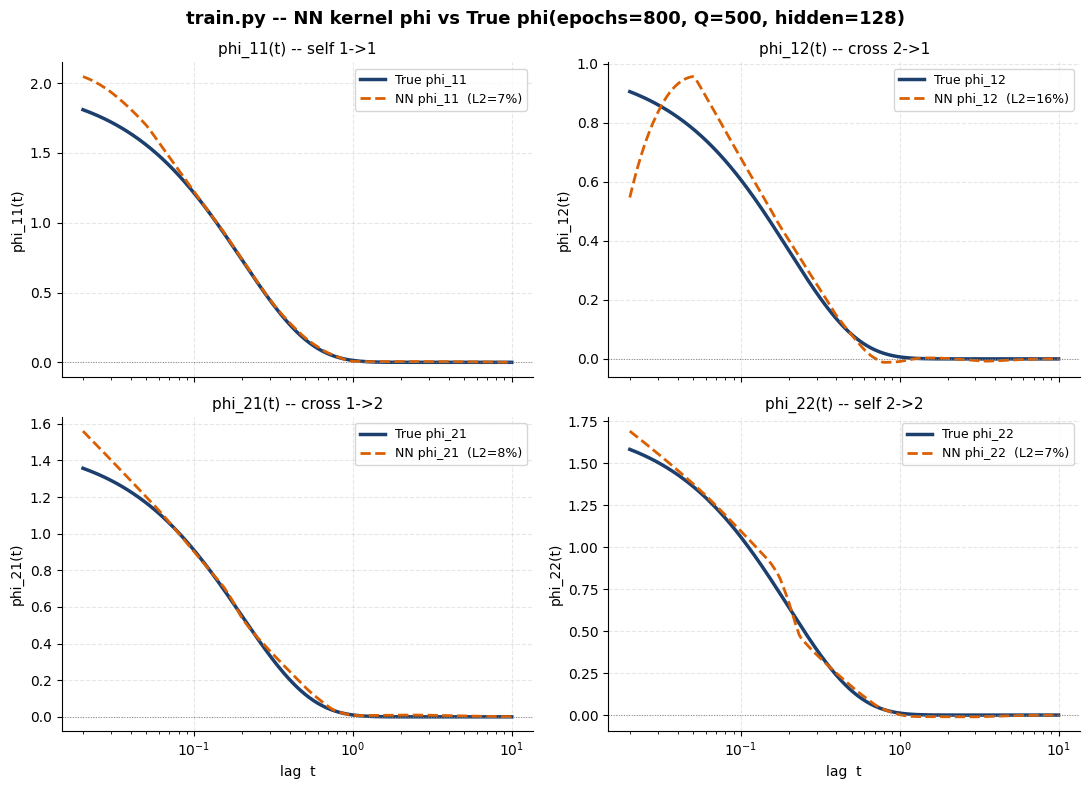

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from MHP import MHP
from train import Config, train_all_rows, predict_row_on_grid

# Simulate data and save to CSV (train.py expects a CSV with time/type/mark columns)
alpha = np.array([[0.40, 0.20],
                  [0.30, 0.35]])
omega = 5.0
mu    = np.array([0.3, 0.2])

hp  = MHP(Phi=alpha, mu=mu, omega=omega)
hp.check_stability()
raw = hp.generate(horizon=10_000.0,  seed=0)
print(f"Simulated {len(raw):,} events")

df = pd.DataFrame({
    "time": raw[:, 0],
    "type": raw[:, 1].astype(int),
    "mark": np.ones(len(raw)),
})
data_path = "events_sim.csv"
df.to_csv(data_path, index=False)
print(f"Saved to {data_path}")

config = Config(
    D=2,
    M=1,
    T=10.0,
    use_exact_mark_grid=True,
    epochs=800,
    n_collocation=1024,
    n_validation=256,
    batch_size=32,
    hidden_dim=128,
    dgm_layers=8,
    n_quadrature=500,
    print_every=100,
    device="cpu",
    seed=42,
    weight_eps=5.0,
    short_time_fraction=0.3,
    boundary_weight=0.1,
    use_cross_kernel_weighting=True,
    nlin=50,
    nlog=100,
    h=1.0,
    learning_rate=1e-3,
)


results = train_all_rows(data_path=data_path, config=config)
models   = results["models"]
stats    = results["stats"]
print("Training complete")

# Plot predicted kernels vs ground truth
t_fine   = np.logspace(np.log10(stats["effective_t_min"]), np.log10(config.T), 300)
phi_true = np.zeros((config.D, config.D, len(t_fine)))
phi_pred = np.zeros_like(phi_true)

for i in range(config.D):
    for j in range(config.D):
        phi_true[i, j] = alpha[i, j] * omega * np.exp(-omega * t_fine)

for i, model in enumerate(models):
    grid = predict_row_on_grid(model, t_fine, stats["bin_centers"], config)
    for j in range(config.D):
        phi_pred[i, j] = grid[:, 0, j]  # grid shape is (n_t, M, D); M=1

lbl = {(0,0): "self 1->1", (0,1): "cross 2->1",
       (1,0): "cross 1->2", (1,1): "self 2->2"}

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
fig.suptitle(
    "train.py -- NN kernel phi vs True phi"
    f"(epochs={config.epochs}, Q={config.n_quadrature}, hidden={config.hidden_dim})",
    fontsize=13, fontweight="bold")
for i in range(config.D):
    for j in range(config.D):
        ax  = axes[i, j]
        pt  = phi_true[i, j]
        pp  = phi_pred[i, j]
        rl2 = (np.sqrt(np.trapezoid((pt - pp)**2, t_fine))
               / (np.sqrt(np.trapezoid(pt**2, t_fine)) + 1e-12)) * 100
        ax.plot(t_fine, pt, color="#1C3F6E", lw=2.5, label=f"True $\phi_{i+1}{j+1}$")
        ax.plot(t_fine, pp, color="#D95F02", lw=2.0, ls="--",
                label=f"NN $\phi_{i+1}{j+1}$  (L2={rl2:.0f}%)")
        ax.axhline(0, color="gray", lw=0.7, ls=":")
        ax.set_xscale("log")
        ax.set_title(f"$\phi_{i+1}{j+1}(t)$ -- {lbl[(i,j)]}", fontsize=11)
        ax.set_ylabel(f"$\phi_{i+1}{j+1}(t)$")
        if i == 1:
            ax.set_xlabel("lag  t")
        ax.legend(fontsize=9)
        ax.grid(ls="--", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

Discontinu Kernel TESTING

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.ndimage import gaussian_filter1d
from data import EventData
from StatisticEstimators import *
from MHP import MHP

def phi_11(t):
    t = np.asarray(t, dtype=float)
    return np.where((t >= 0.0) & (t < 0.15), 0.0,
           np.where((t >= 0.15) & (t < 0.40), 0.8,
           np.where((t >= 0.40) & (t < 0.90), 0.6, 0.0)))

def phi_12(t):
    t = np.asarray(t, dtype=float)
    return np.where((t >= 0.0) & (t < 0.25), 0.0,
           np.where((t >= 0.25) & (t < 0.55), 0.5,
           np.where((t >= 0.55) & (t < 1.00), 0.25, 0.0)))

def phi_21(t):
    t = np.asarray(t, dtype=float)
    return np.where((t >= 0.0) & (t < 0.10), 0.0,
           np.where((t >= 0.10) & (t < 0.35), 0.2,
           np.where((t >= 0.35) & (t < 0.75), 0.4, 0.0)))

def phi_22(t):
    t = np.asarray(t, dtype=float)
    return np.where((t >= 0.0) & (t < 0.20), 0.0,
           np.where((t >= 0.20) & (t < 0.50), 0.4,
           np.where((t >= 0.50) & (t < 1.10), 0.5, 0.0)))

Phi = np.array([[phi_11, phi_12],
                [phi_21, phi_22]], dtype=object)

mu = np.array([0.25, 0.20])

hp = MHP(Phi=Phi, mu=mu, T_max=5.0)
hp.check_stability()
print("Lambda_true =", hp.stationary_rate())
horizon = 1000
raw = hp.generate(horizon=horizon, seed=0)

print(f"Simulated {len(raw)} events")


events = EventData(
    times  = raw[:, 0],
    types  = raw[:, 1].astype(int),
    marks  = np.ones(len(raw)),   # dummy  unused cause we can't find some in this simulation only for like csv
    horizon= horizon,
)

# Estimate statistics 
import numpy as np

def compute_lambda_true_custom(hp, T_max_integral=50.0, n_grid=20000):
    D = hp.D
    t_grid = np.linspace(1e-8, T_max_integral, n_grid)

    K = np.zeros((D, D))
    for i in range(D):
        for j in range(D):
            vals = hp.Phi[i, j](t_grid)
            K[i, j] = np.trapezoid(vals, t_grid)

    Lambda_true = np.linalg.solve(np.eye(D) - K, hp.mu)
    return K, Lambda_true

K, Lambda_true = compute_lambda_true_custom(hp, T_max_integral=10.0, n_grid=10000)


Lambda_hat       = estimate_Lambda(events)
lag_max, h       = 1.0, 0.15
G_hat, t_grid, _ = estimate_G(events, Lambda_hat,
                               lag_max=lag_max, h=h, n_lin=8, n_log=30)
# Spline-smooth in log-time 
G_smooth = smooth_G_spline(G_hat, t_grid, smooth_factor=None)

print(f"True  $\lambda$ : {np.round(Lambda_true, 4)}")
print(f"Est.  $\lambda$ : {np.round(Lambda_hat,  4)}")
print(f"Error   : {np.round(np.abs(Lambda_hat - Lambda_true), 5)}")

#true G 
A   = omega * (alpha - np.eye(D))
B   = omega * alpha @ np.diag(Lambda_true)
Gss = -np.linalg.inv(A) @ B
C   = alpha * omega

G_true = np.zeros((len(t_grid), D, D))
for k, t in enumerate(t_grid):
    G_true[k] = expm(A * t) @ C + Gss

# Plot 
CT, CE, CS = "#1C3F6E", "#D95F02", "#2CA02C"
label = {(0,0): "self  1→1", (0,1): "cross 2→1",
         (1,0): "cross 1→2", (1,1): "self  2→2"}

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
fig.suptitle(
    rf"$\hat G$ (StatisticEstimators.py + EventData)  vs  True $G$"
    f"\nT={horizon:.0f},  N={len(raw):,},  "
    r"$\alpha$=[[0.40,0.20],[0.30,0.35]],  $\omega$=5",
    fontsize=13, fontweight="bold"
)

for i in range(D):
    for j in range(D):
        ax = axes[i, j]
        tv = G_true[:, i, j]
        ev = G_hat[i, j, :]
        sv = G_smooth[i, j, :]

        rl2_raw = (np.sqrt(np.trapezoid((tv-ev)**2, t_grid))
                   / (np.sqrt(np.trapezoid(tv**2, t_grid)) + 1e-12)) * 100
        rl2_smo = (np.sqrt(np.trapezoid((tv-sv)**2, t_grid))
                   / (np.sqrt(np.trapezoid(tv**2, t_grid)) + 1e-12)) * 100

        ax.plot(t_grid, ev, color=CE, lw=0.9, alpha=0.5,
                label=rf"$\hat G^{{{i+1}{j+1}}}$ raw  (L2={rl2_raw:.0f}%)")
        ax.plot(t_grid, sv, color=CS, lw=2.0, ls="-.",
                label=rf"$\hat G^{{{i+1}{j+1}}}$ smoothed  (L2={rl2_smo:.0f}%)")
        ax.plot(t_grid, tv, color=CT, lw=2.5,
                label=rf"True $G^{{{i+1}{j+1}}}$")
        ax.axhline(0, color="gray", lw=0.7, ls=":")

        ax.set_title(rf"$G^{{{i+1}{j+1}}}(t)$ — {label[(i,j)]}", fontsize=11)
        ax.set_ylabel(rf"$G^{{{i+1}{j+1}}}(t)$")
        if i == 1:
            ax.set_xlabel("lag $t$")
        ax.legend(fontsize=8.5, loc="upper right")
        ax.grid(ls="--", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

Max eigenvalue 0.6983097678335175
Stable
Lambda_true = [0.84126531 0.64957867]


KeyboardInterrupt: 

In [ ]:

import torch
import copy
import numpy as np
import matplotlib.pyplot as plt
from models import KernelRowNet
from StatisticEstimators import build_H
from loss import temporal_weights

torch.manual_seed(42)
device = torch.device("cpu")

# Hyperparameters 
HIDDEN      = 256
LAYERS      = 32
LR0         = 1e-3
EPOCHS      = 800
Q           = 250       
EPS_W       = 5.0       
PRINT_EVERY = 100

#  grid 
t_min  = t_grid[0]
T      = lag_max

e1 = np.logspace(np.log10(t_min), np.log10(0.05),  80 + 1)  # short lag
e2 = np.logspace(np.log10(0.05),  np.log10(0.3),   100 + 1) # peak region  
e3 = np.logspace(np.log10(0.3),   np.log10(T),      70 + 1) # tail

edges = np.unique(np.concatenate([e1, e2[1:], e3[1:]]))
t_np  = 0.5 * (edges[:-1] + edges[1:])
w_np  = np.diff(edges)

"""edges  = np.logspace(np.log10(t_min), np.log10(T), Q + 1)
t_np   = 0.5 * (edges[:-1] + edges[1:])   # midpoints  [Q]
w_np   = np.diff(edges)                    # widths      [Q]
"""
t_th   = torch.tensor(t_np, dtype=torch.float32)
w_th   = torch.tensor(w_np, dtype=torch.float32)

# Build H for the integral
H_func = build_H(G_smooth, t_grid, Lambda_hat)
diff   = t_np[:, None] - t_np[None, :]         
H_np   = np.zeros((Q, Q, D, D))
for k in range(D):
    for j in range(D):
        H_np[:, :, k, j] = H_func(k, j, diff.ravel()).reshape(Q, Q)
H_th = torch.tensor(H_np, dtype=torch.float32)  


# G target resampled onto quadrature grid 
G_on_quad = np.zeros((D, D, Q))
for i in range(D):
    for j in range(D):
        G_on_quad[i, j] = np.interp(t_np, t_grid, G_smooth[i, j])
G_quad_th = torch.tensor(G_on_quad, dtype=torch.float32)  # [D, D, Q]

#  Cross-kernel ζ weights 
areas     = torch.trapezoid(G_quad_th.abs(), t_th, dim=2)  
inv_areas = 1.0 / areas.clamp_min(1e-8)
zeta      = inv_areas / inv_areas.sum()                    # [D, D]
print(f"$\zeta$ weights:\n{zeta.numpy().round(4)}")


def train_row_paper(row_i):
    """
    Train one KernelRowNet for row i using the paper's full loss.
    Collocation = quadrature grid (Q fixed points, sorted by time).
    Each epoch:
      1. [no_grad] compute residuals → temporal weights ω  (Eq. 22)
      2. forward pass to loss = mean(\zeta_{ij} · \omega_{nj} · residual^2_{nj})
    LR schedule: \gamma_e = \gamma_0 · 100^{-(e+1)/E}   (Algorithm 1)
    """
    model   = KernelRowNet(input_dim=2, hidden_dim=HIDDEN, output_dim=D, n_layers=LAYERS).to(device)
    opt     = torch.optim.Adam(model.parameters(), lr=LR0)

    log_t    = torch.log10(t_th.clamp_min(1e-8))   # [Q]
    x_dummy  = torch.ones_like(log_t)               # unmarked: x = 1
    target   = G_quad_th[row_i].T                   # [Q, D]
    zeta_row = zeta[row_i]                           # [D]

    best_val, best_epoch, best_state = float("inf"), -1, None

    for ep in range(EPOCHS):
        # LR decay 
        lr = LR0 * (10.0 ** (-(ep + 1) / EPOCHS))
        for g in opt.param_groups:
            g["lr"] = lr

        # Temporal weights 
        model.eval()
        with torch.no_grad():
            phi_ng   = model(log_t, x_dummy)                        # [Q, D]
            phi_w_ng = phi_ng * w_th[:, None]                       # [Q, D]
            int_ng   = torch.einsum("qk,nqkj->nj", phi_w_ng, H_th) # [Q, D]
            res_ng   = phi_ng + int_ng - target                     # [Q, D]
            omega_w  = temporal_weights(res_ng, eps=EPS_W)          # [Q, D]

        # Forward + weighted loss 
        model.train()
        opt.zero_grad()
        phi      = model(log_t, x_dummy)                            # [Q, D]
        phi_w    = phi * w_th[:, None]                              # [Q, D]
        integral = torch.einsum("qk,nqkj->nj", phi_w, H_th)        # [Q, D]
        residual = phi + integral - target                          # [Q, D]

        # to check and try other shit
        loss = (zeta_row * omega_w.detach() * residual.square()).mean()
        loss.backward()
        opt.step()

        # Validation to check not sure
        model.eval()
        with torch.no_grad():
            phi_v    = model(log_t, x_dummy)
            int_v    = torch.einsum("qk,nqkj->nj", phi_v * w_th[:, None], H_th)
            val_loss = (phi_v + int_v - target).square().mean().item()

        if val_loss < best_val:
            best_val, best_epoch = val_loss, ep
            best_state = copy.deepcopy(model.state_dict())

        if ep % PRINT_EVERY == 0 or ep == EPOCHS - 1:
            print(f"  [row {row_i}] ep {ep:04d}  lr={lr:.3e}  "
                  f"train={loss.item():.4e}  val={val_loss:.4e}  "
                  f"best={best_val:.4e}@ep{best_epoch}")

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"  to loaded best checkpoint (ep {best_epoch}, val={best_val:.4e})")
    return model


# Train all rows
trained_models = []
for row_i in range(D):
    print(f"\n{'='*60}\nTraining row {row_i}\n{'='*60}")
    m = train_row_paper(row_i)
    trained_models.append(m)


#  Predict
t_fine   = np.logspace(np.log10(t_np[0]), np.log10(t_np[-1]), 300)
log_fine = torch.log10(torch.tensor(t_fine, dtype=torch.float32).clamp_min(1e-8))
x_fine   = torch.ones_like(log_fine)

phi_pred      = np.zeros((D, D, len(t_fine)))
phi_true_fine = np.zeros_like(phi_pred)

for i in range(D):
    trained_models[i].eval()
    with torch.no_grad():
        out = trained_models[i](log_fine, x_fine).numpy()  # [L, D]
    phi_pred[i] = out.T

for i in range(D):
    for j in range(D):
        phi_true_fine[i, j] = alpha[i, j] * omega * np.exp(-omega * t_fine)

# Plot 
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
fig.suptitle(
    r"NN kernel $\hat\phi$ vs True $\phi$  —  paper loss"
    f"\n(temporal $\omega$ + cross-kernel $\zeta$ + LR decay,  epochs={EPOCHS},  Q={Q})",
    fontsize=13, fontweight="bold"
)
lbl = {(0,0): "self 1→1", (0,1): "cross 2→1",
       (1,0): "cross 1→2", (1,1): "self 2→2"}

for i in range(D):
    for j in range(D):
        ax  = axes[i, j]
        pt  = phi_true_fine[i, j]
        pp  = phi_pred[i, j]
        rl2 = (np.sqrt(np.trapezoid((pt - pp)**2, t_fine))
               / (np.sqrt(np.trapezoid(pt**2, t_fine)) + 1e-12)) * 100

        ax.plot(t_fine, pt, color="#1C3F6E", lw=2.5, label=f"True  $\phi_{i+1}{j+1}$")
        ax.plot(t_fine, pp, color="#D95F02", lw=2.0, ls="--",
                label=f"NN  $\phi_{i+1}{j+1}$  (L2={rl2:.0f}%)")
        ax.axhline(0, color="gray", lw=0.7, ls=":")
        ax.set_xscale("log")
        ax.set_title(f"$\phi_{i+1}{j+1}(t)$ — {lbl[(i,j)]}", fontsize=11)
        ax.set_ylabel(f"$\phi_{i+1}{j+1}(t)$")
        if i == 1:
            ax.set_xlabel("lag  t")
        ax.legend(fontsize=9)
        ax.grid(ls="--", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()
